In [1]:
import torch
import torch.nn as nn
import numpy as np
from graphviz import Digraph

In [2]:
torch.cuda.is_available()

False

In [3]:
torch.backends.mps.is_available()

True

In [4]:
torch.backends.mps.get_core_count()

20

In [5]:
torch.backends.mps.get_name()

'Apple M4 Pro'

## Tensors

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: mps


In [7]:
t1 = torch.tensor([
    [1,2],
    [3,4],
]).to(device)

t1

tensor([[1, 2],
        [3, 4]], device='mps:0')

In [28]:
t1.unsqueeze(0).shape

torch.Size([1, 2, 2])

In [ ]:
arr = np.array([
    [1,2],  
    [3,4],
])

t2 = torch.from_numpy(arr)
print(t2)

tensor([[1, 2],
        [3, 4]])


In [34]:
torch.rand((3,4))

tensor([[0.0626, 0.2240, 0.5401, 0.4040],
        [0.2143, 0.7114, 0.1160, 0.5595],
        [0.9337, 0.9952, 0.1496, 0.3102]])

In [38]:
t1.to(device='mps')
# t1.device

tensor([[1, 2],
        [3, 4]], device='mps:0')

numoy only works on CPU. If I wanna convert from np to torch tensors, i can send to GPU. However, if i wanna convert back to np, i have to first send back to CPU then convert to np

In [50]:
arr.to_device('mps')

ValueError: Unsupported device: mps. Only 'cpu' is accepted.

In [51]:
arr.device

'cpu'

In [53]:
t3 = torch.from_numpy(arr).to(device)
t3

tensor([[1, 2],
        [3, 4]], device='mps:0')

In [56]:
arr2 = t3.cpu().numpy()
arr2

array([[1, 2],
       [3, 4]])

In [57]:
arr2.device

'cpu'

# Indexing

In [34]:
# A simple, easy-to-read tensor
x = torch.tensor([[0, 1, 2, 3],
                  [4, 5, 6, 7],
                  [8, 9, 10, 11]])

# Get the second row (at index 1)
row_1 = x[1]
print(f"Row 1: {row_1}\n")

# Get the third column (at index 2)
col_2 = x[:, 2]
print(f"Column 2: {col_2}\n")

# Get a specific element (row 1, column 3)
element_1_3 = x[1, 3]
print(f"Element at (1, 3): {element_1_3}")

Row 1: tensor([4, 5, 6, 7])

Column 2: tensor([ 2,  6, 10])

Element at (1, 3): 7


In [35]:
x = torch.tensor([[0, 1, 2, 3], [4, 5, 6, 7]])

# Step 1: Create the boolean mask
mask = x > 3
print(f"The Boolean Mask (x > 3):\n {mask}\n")

# Step 2: Apply the mask to the tensor
selected_elements = x[mask]
print(f"Selected elements: {selected_elements}")

The Boolean Mask (x > 3):
 tensor([[False, False, False, False],
        [ True,  True,  True,  True]])

Selected elements: tensor([4, 5, 6, 7])


# Auto Grad

In [ ]:
# shape (4,3) 4 samples, 3 features
                       # x1  x2   x3
x_data = torch.tensor([[1.0, 3.2, 4.5], 
                       [2.0, 8.2, 4.4], 
                       [3.0, 2.1, 5.6], 
                       [4.0, 4.3, 7.2]])

# shape (3,1) 3 weights
# requires_grad=True -> autograd will track all operations 
# on w and b, and will be able to compute gradients 
# for them during backpropagation
w = torch.tensor([ [1.0], # w1
                   [2.3], # w2
                   [4.2]],# w3
                 requires_grad=True)
#matmul: w1x1 + w2x2 + w3x3 for each sample
b = torch.tensor([[5.0]], requires_grad=True)

y = x_data @ w
z = y + b
print(y)
print(z)




tensor([[27.2600],
        [39.3400],
        [31.3500],
        [44.1300]], grad_fn=<MmBackward0>)
tensor([[32.2600],
        [44.3400],
        [36.3500],
        [49.1300]], grad_fn=<AddBackward0>)


In [11]:
y.grad_fn

In [31]:
# out features means the number of neurons in the layer
l = nn.Linear(in_features=3, out_features=1)
z = l(x_data) 
out = F.relu(z)
print(z)
print()
print(out)
print()
print(l.weight)
print()
print(l.bias)

# same as x_data @ l.weight.T + l.bias
# l is doing z = X @ W + b

tensor([[1.5395],
        [3.5436],
        [0.6284],
        [1.6446]], grad_fn=<AddmmBackward0>)

tensor([[1.5395],
        [3.5436],
        [0.6284],
        [1.6446]], grad_fn=<ReluBackward0>)

Parameter containing:
tensor([[-0.3014,  0.4648,  0.1844]], requires_grad=True)

Parameter containing:
tensor([-0.4763], requires_grad=True)


In [12]:
# @ vs *: matrix multiplication vs element-wise multiplication
t1 = torch.tensor([[1,2],[3,4]], dtype=torch.float32)
t2 = torch.tensor([[5,6],[7,8]], dtype=torch.float32)
print("t1 @ t2:\n", t1 @ t2)
print()
print("t1 * t2:\n", t1 * t2)

t1 @ t2:
 tensor([[19., 22.],
        [43., 50.]])

t1 * t2:
 tensor([[ 5., 12.],
        [21., 32.]])


In [66]:
def draw_dot_torch(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    seen = set()

    def build(node):
        if node in seen:
            return
        seen.add(node)

        if hasattr(node, 'variable'):  # AccumulateGrad wraps leaf tensors
            t = node.variable
            uid = str(id(node))
            label_text = getattr(t, 'label', 'leaf')  # Use .label if set
            dot.node(uid, label="{ %s | %s | grad %s }" % (label_text, t.data.tolist(), t.grad.tolist() if t.grad is not None else 'None'), shape='record')
        else:
            uid = str(id(node))
            op = type(node).__name__.replace('Backward0', '').replace('Backward', '')
            dot.node(uid, label=op)
            for child, _ in node.next_functions:
                if child is not None:
                    dot.edge(str(id(child)), uid)
                    build(child)

    label_text = getattr(root, 'label', 'output')  # Use .label if set
    dot.node(str(id(root)), label="{ %s | %s }" % (label_text, root.data.tolist()), shape='record')
    if root.grad_fn:
        dot.edge(str(id(root.grad_fn)), str(id(root)))
        build(root.grad_fn)

    return dot

In [59]:
a = torch.tensor([1.2, 2.33, 3.5, 7.], requires_grad=True)
b = torch.tensor([4.1, 5.2, 6.3, 8.4], requires_grad=True)
c = 3 * a**3 + b**2
print(c)

tensor([  21.9940,   64.9880,  168.3150, 1099.5599], grad_fn=<AddBackward0>)


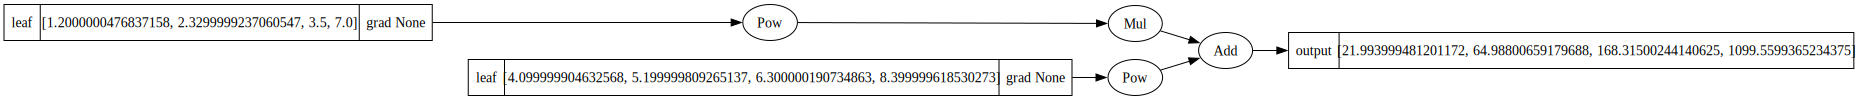

In [67]:
draw_dot_torch(c)

In [69]:
c.backward(torch.ones_like(c))

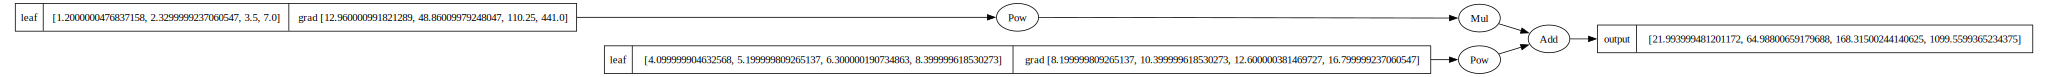

In [70]:
draw_dot_torch(c)

In [71]:
a.grad

tensor([ 12.9600,  48.8601, 110.2500, 441.0000])

In [72]:
# dcda = 9 * a**2
9 * a**2

tensor([ 12.9600,  48.8601, 110.2500, 441.0000], grad_fn=<MulBackward0>)

In [74]:
b.grad

tensor([ 8.2000, 10.4000, 12.6000, 16.8000])

In [73]:
# dc/db = 2 * b
2 * b

tensor([ 8.2000, 10.4000, 12.6000, 16.8000], grad_fn=<MulBackward0>)

In [75]:
a = torch.tensor([1.2, 2.33, 3.5, 7.], requires_grad=True)
b = torch.tensor([4.1, 5.2, 6.3, 8.4], requires_grad=True)
c = 3 * a**3 + b**2
e = c - 10
f = e**a * c
g = f / e
print(g)

tensor([3.6149e+01, 1.3409e+04, 5.3080e+07, 1.8396e+21],
       grad_fn=<DivBackward0>)


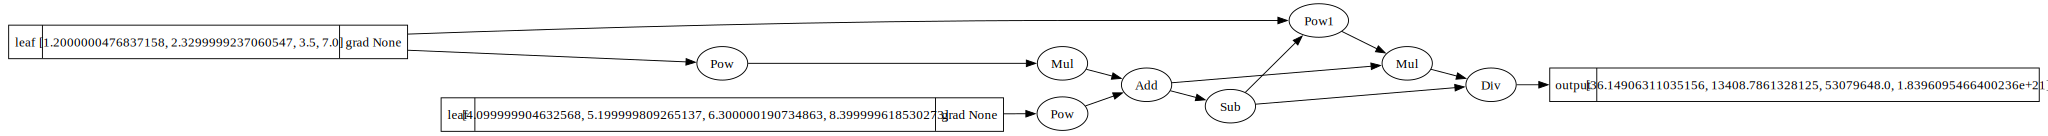

In [76]:
draw_dot_torch(g)

In [77]:
g.backward(torch.ones_like(g))

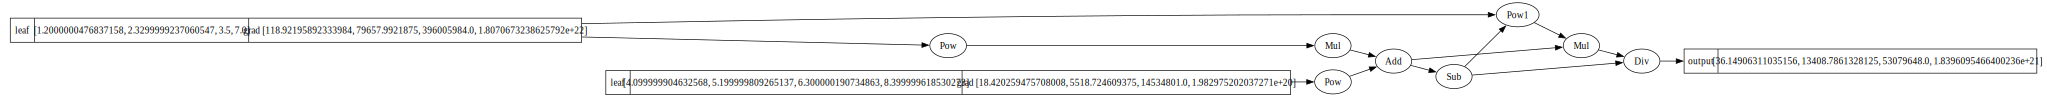

In [78]:
draw_dot_torch(g)

# Neural Networks

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [83]:
X, y = datasets.load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [84]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((512, 30), (57, 30), (512,), (57,))

In [85]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [86]:
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float().unsqueeze(1)
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float().unsqueeze(1)

In [87]:
y_train.shape

torch.Size([512, 1])

In [95]:
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [96]:
class BCNet(nn.Module):
    def __init__(self):
        super(BCNet, self).__init__()
        
        self.fc1 = nn.Linear(30, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)
    
    def forward(self, x): # similar to __call__
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

In [98]:
model = BCNet()
model(X_train[:5])

tensor([[0.4644],
        [0.4424],
        [0.4480],
        [0.4468],
        [0.4595]], grad_fn=<SigmoidBackward0>)

In [99]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [100]:
epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad() # reset gradients
        outputs = model(X_batch) # forward pass
        loss = criterion(outputs, y_batch) # compute loss
        loss.backward() # compute gradients
        optimizer.step() # update parameters
        
        running_loss += loss.item() * X_batch.size(0)
        
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader.dataset):.4f}")
        

Epoch 1/100, Loss: 0.6618
Epoch 2/100, Loss: 0.6531
Epoch 3/100, Loss: 0.6408
Epoch 4/100, Loss: 0.6226
Epoch 5/100, Loss: 0.6020
Epoch 6/100, Loss: 0.5856
Epoch 7/100, Loss: 0.5729
Epoch 8/100, Loss: 0.5622
Epoch 9/100, Loss: 0.5515
Epoch 10/100, Loss: 0.5407
Epoch 11/100, Loss: 0.5294
Epoch 12/100, Loss: 0.5187
Epoch 13/100, Loss: 0.5091
Epoch 14/100, Loss: 0.5012
Epoch 15/100, Loss: 0.4949
Epoch 16/100, Loss: 0.4903
Epoch 17/100, Loss: 0.4865
Epoch 18/100, Loss: 0.4838
Epoch 19/100, Loss: 0.4815
Epoch 20/100, Loss: 0.4797
Epoch 21/100, Loss: 0.4782
Epoch 22/100, Loss: 0.4770
Epoch 23/100, Loss: 0.4759
Epoch 24/100, Loss: 0.4749
Epoch 25/100, Loss: 0.4741
Epoch 26/100, Loss: 0.4734
Epoch 27/100, Loss: 0.4727
Epoch 28/100, Loss: 0.4721
Epoch 29/100, Loss: 0.4716
Epoch 30/100, Loss: 0.4711
Epoch 31/100, Loss: 0.4707
Epoch 32/100, Loss: 0.4704
Epoch 33/100, Loss: 0.4700
Epoch 34/100, Loss: 0.4697
Epoch 35/100, Loss: 0.4693
Epoch 36/100, Loss: 0.4690
Epoch 37/100, Loss: 0.4686
Epoch 38/1

In [101]:
# evalute on test set
with torch.no_grad():
    model.eval()
    test_outputs = model(X_test)
    test_loss = criterion(test_outputs, y_test)
    accuracy = ((test_outputs > 0.5) == y_test).float().mean()
    print(f"Test Loss: {test_loss.item():.4f}")
    print(f"Test Accuracy: {accuracy.item():.4f}")
    

Test Loss: 0.4396
Test Accuracy: 0.9825


# Anatomy of NNs

## Neuron

In [36]:
import numpy as np
class Neuron:
    def __init__(self, in_features):
        # z = w @ x + b --> y = act(z)
        self.w = [np.random.uniform(-1,1) for _ in range(in_features)]           # for each in_feature we wanna generagte a w
        self.b = np.random.uniform(-1,1)
    def __call__(self, x):
        z = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        y = np.tanh(z)
        return y

In [39]:
x = np.random.uniform(-3, 3, 10)
n = Neuron(len(x))
n(x)

np.float64(-0.5676755093864921)

# CNNs

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 1. Convolution Layer
        # in_channels=3 (RGB), out_channels=16 (we want to find 16 different features)
        # kernel_size=3 (a 3x3 sliding window)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        
        # 2. Max Pooling Layer
        # kernel_size=2 (halves the height and width of the image)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        # Apply Convolution -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))
        return x

# Example: A 64x64 RGB image
example_input = torch.randn(1, 3, 64, 64) 
model = SimpleCNN()
output = model(example_input)

print(f"Input shape: {example_input.shape}") # [1, 3, 64, 64]
print(f"Output shape: {output.shape}")      # [1, 16, 32, 32]

Input shape: torch.Size([1, 3, 64, 64])
Output shape: torch.Size([1, 16, 32, 32])


In [ ]:
# class myCNN(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
#         # self.relu = nn.ReLU()
#         self.pool1 = nn.MaxPool2d()
        
#         self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
#         # self.relu = nn.ReLU()
#         self.pool2 = nn.MaxPool2d()
        
#     def forward(x):
        
#         x = self.pool1(F.relu(self.conv1(x)))
#         x = self.pool2(F.relu(self.conv2(x)))
        
#         return x
        